# SPX vs VIX: Regime-Dependent Volatility Feedback

## The story in plain terms

The S&P 500 (SPX) is a stock market index that tracks 500 large US companies --
when people say "the market" went up or down, they usually mean this index.

The VIX is often called the market's "fear gauge." It's calculated from the
prices investors pay for options on the S&P 500.
When investors expect big swings ahead, those options get more expensive, and
VIX rises. Importantly, VIX is not an independent market -- it is mathematically
derived from S&P 500 option prices. Think of SPX and VIX as two different
instruments measuring the same underlying market mood, not two separate markets
that happen to interact.

There's a well-known pattern in finance called the "leverage effect": when the
stock market drops sharply, VIX tends to spike sharply on the very same day.
This happens because a falling stock price makes a company look riskier
(its debt becomes a bigger share of its value), and because fear and uncertainty
rise during selloffs. This case study tests whether our toolkit can detect this
real, well-documented relationship using Granger causality, Transfer Entropy,
CCM, DTW, and surrogate significance testing -- and whether the relationship
gets stronger during a market crisis.

## Why we split the data into three time periods

Markets don't behave the same way all the time. We compare:

- **Full sample (2015-2024)**: ten years of everything mixed together --
  quiet periods, crashes, recoveries, all blended into one dataset.
- **Calm period (2017)**: one of the quietest years in stock market history --
  the market rose steadily with almost no big daily swings, and VIX sat near
  record lows for most of the year.
- **Stress period (2020)**: the COVID-19 crash year. The S&P 500 fell about
  34% in five weeks in February-March 2020, then recovered sharply -- one of
  the fastest, most extreme market moves in modern history. VIX hit its
  highest level ever recorded during this period.

By comparing calm vs. stress separately (instead of only looking at the ten-year
blend), we can ask a sharper question: does the SPX-VIX relationship change
character when markets are panicking versus when they're quiet? Financial
research suggests it should get stronger and more one-directional during
crises, so this is what we're testing for.

See `01_synthetic_validation.ipynb` for correctness validation on data where
we control the true causal direction ourselves.

In [10]:
from pathlib import Path
import sys
import contextlib
import io

project_root = Path.cwd().resolve()
if not (project_root / "src").exists() and (project_root.parent / "src").exists():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

with contextlib.redirect_stdout(io.StringIO()):
    import dtw  # noqa: F401

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import PreprocessingConfig, AnalysisConfig, download_yfinance_series, run_analysis_pipeline

pd.set_option("display.float_format", lambda v: f"{v:.6f}")

In [11]:
loaded_full = download_yfinance_series(
    "^GSPC", "^VIX",
    start="2015-01-01", end="2024-12-31",
    name_one="S&P 500", name_two="VIX",
)

print(loaded_full.left.head())
print(loaded_full.right.head())
print(f"S&P 500 obs: {len(loaded_full.left)}, VIX obs: {len(loaded_full.right)}")

Date
2015-01-02   2058.199951
2015-01-05   2020.579956
2015-01-06   2002.609985
2015-01-07   2025.900024
2015-01-08   2062.139893
Name: S&P 500, dtype: float64
Date
2015-01-02   17.790001
2015-01-05   19.920000
2015-01-06   21.120001
2015-01-07   19.309999
2015-01-08   17.010000
Name: VIX, dtype: float64
S&P 500 obs: 2515, VIX obs: 2515


In [12]:
regimes = {
    "full_sample": ("2015-01-01", "2024-12-31"),
    "calm_2017": ("2017-01-01", "2017-12-31"),
    "stress_2020": ("2020-01-01", "2020-12-31"),
}

def slice_pair(loaded, start, end):
    left = loaded.left.loc[start:end]
    right = loaded.right.loc[start:end]
    common_index = left.index.intersection(right.index)
    return left.loc[common_index], right.loc[common_index]

In [13]:
spx_vix_preprocessing = PreprocessingConfig(
    base_representation="log_returns",
    standardize=True,
)


REGIME: full_sample (2015-01-01 to 2024-12-31)
Downstream analyses will use S&P 500 and VIX.
Doing ADF test...

--------------------------------------------------------------------------------
ADF / unit-root test summary for S&P 500
--------------------------------------------------------------------------------
Observations:         2504
ADF statistic:        -15.729663
p-value:              0.000000
Used lags:            9
Critical values:      {'1%': -3.4329642237790847, '5%': -2.862694950990622, '10%': -2.5673848250020415}
Conclusion:           Stationary (reject unit-root null at alpha=0.05)
--------------------------------------------------------------------------------

--------------------------------------------------------------------------------
ADF / unit-root test summary for VIX
--------------------------------------------------------------------------------
Observations:         2506
ADF statistic:        -20.892764
p-value:              0.000000
Used lags:            

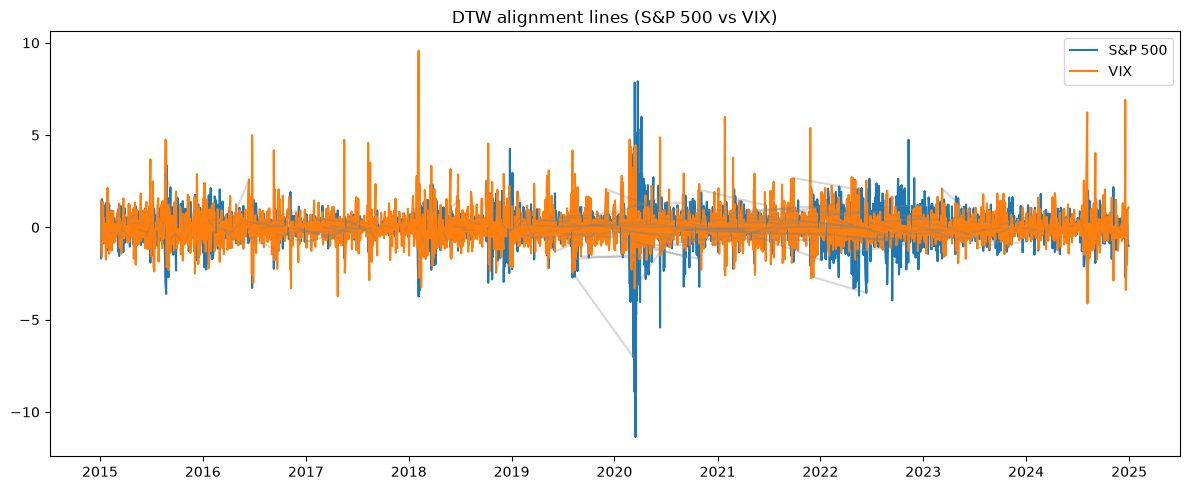

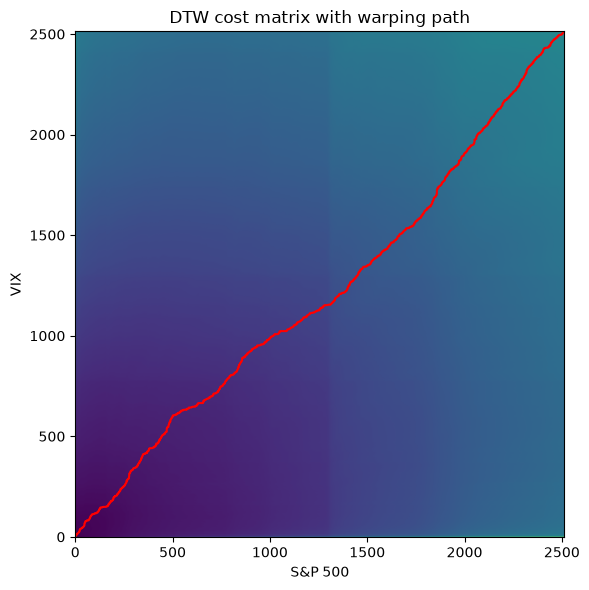


GRANGER CAUSALITY REPORT

Direction: S&P 500 -> VIX
     direction  lag    f_stat  p_value
S&P 500 -> VIX    1 14.505303 0.000143
S&P 500 -> VIX    2  7.658574 0.000483
S&P 500 -> VIX    3  4.923634 0.002062
S&P 500 -> VIX    4  3.318684 0.010139
S&P 500 -> VIX    5  2.980148 0.010953

Direction: VIX -> S&P 500
     direction  lag    f_stat  p_value
VIX -> S&P 500    1 27.444791 0.000000
VIX -> S&P 500    2 13.762481 0.000001
VIX -> S&P 500    3 10.349615 0.000001
VIX -> S&P 500    4  8.631965 0.000001
VIX -> S&P 500    5  7.043233 0.000002

Summary:
S&P 500 -> VIX: strongest evidence at lag 1 (F=14.505303, p=0.000143117)
VIX -> S&P 500: strongest evidence at lag 1 (F=27.444791, p=1.75078e-07)

Overall stronger direction by max F-stat: VIX -> S&P 500

--------------------------------------------------------------------------------
Shuffle surrogate test for Granger direction S&P 500 -> VIX (maxlag=5)
--------------------------------------------------------------------------------
Real

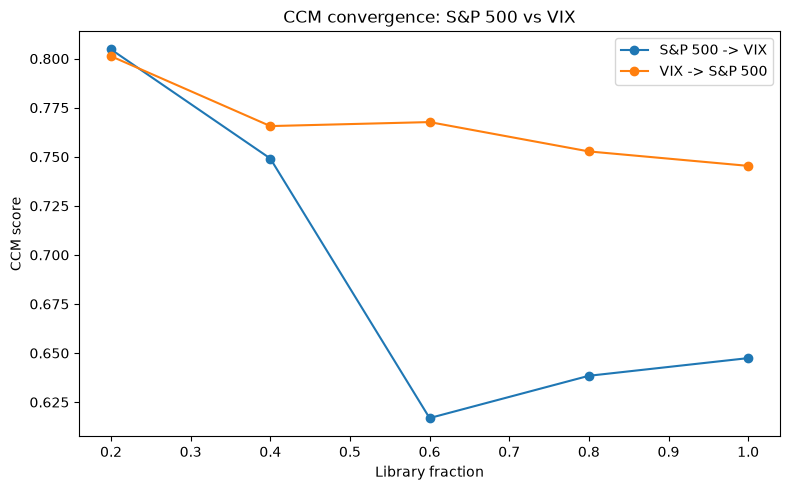


--------------------------------------------------------------------------------
Shuffle surrogate test for CCM direction S&P 500 -> VIX (embed_dim=3, lag=2)
--------------------------------------------------------------------------------
Real value:           0.651195
p-value:              0.0196
Surrogate mean:       0.021440
Surrogate median:     0.018861
Surrogate std:        0.015429
--------------------------------------------------------------------------------

--------------------------------------------------------------------------------
Bootstrap confidence interval for CCM direction S&P 500 -> VIX (embed_dim=3, lag=2)
--------------------------------------------------------------------------------
Real value:           0.651195
95% CI:               [0.001348, 0.061490]
Surrogate mean:       0.021019
Surrogate median:     0.018424
Surrogate std:        0.016033
--------------------------------------------------------------------------------

------------------------------

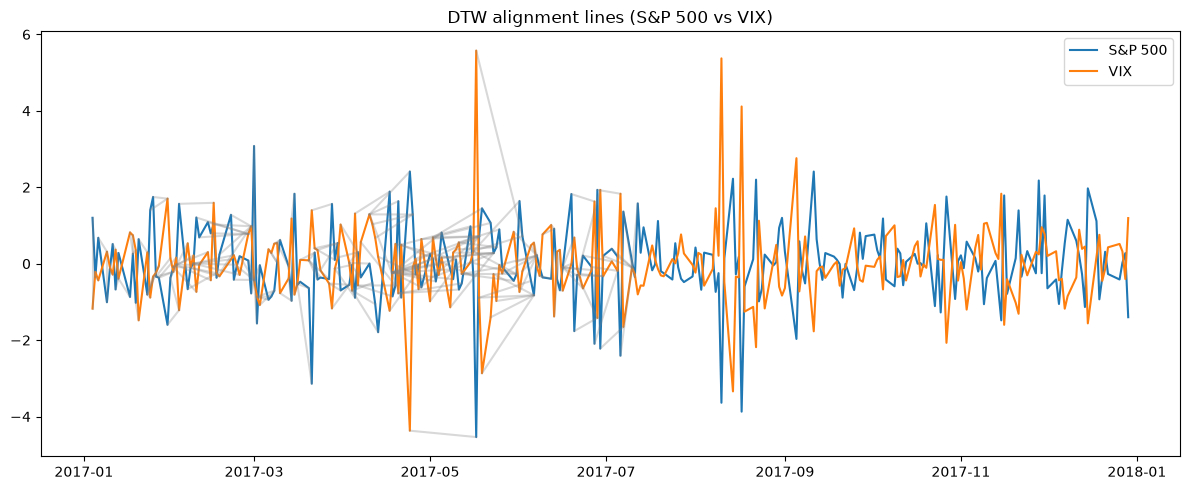

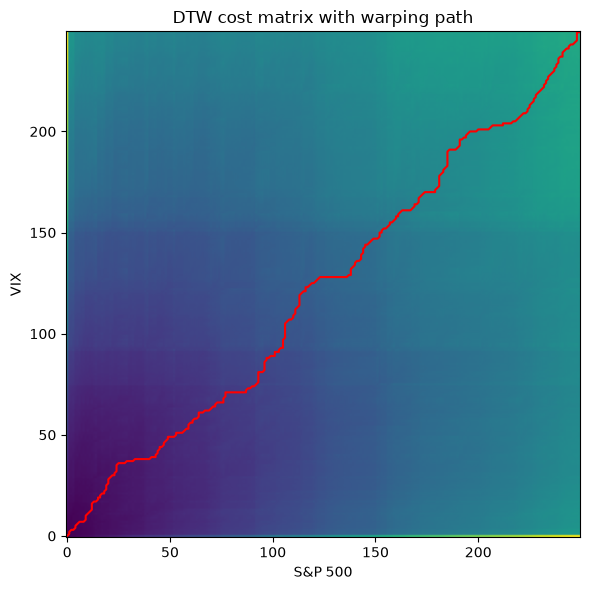


GRANGER CAUSALITY REPORT

Direction: S&P 500 -> VIX
     direction  lag   f_stat  p_value
S&P 500 -> VIX    1 6.269482 0.012932
S&P 500 -> VIX    2 3.973948 0.020034
S&P 500 -> VIX    3 2.367038 0.071497
S&P 500 -> VIX    4 1.700985 0.150498
S&P 500 -> VIX    5 1.428412 0.214750

Direction: VIX -> S&P 500
     direction  lag   f_stat  p_value
VIX -> S&P 500    1 2.014902 0.157027
VIX -> S&P 500    2 0.939452 0.392257
VIX -> S&P 500    3 0.844350 0.470788
VIX -> S&P 500    4 0.656099 0.623116
VIX -> S&P 500    5 1.143209 0.338256

Summary:
S&P 500 -> VIX: strongest evidence at lag 1 (F=6.269482, p=0.0129321)
VIX -> S&P 500: strongest evidence at lag 1 (F=2.014902, p=0.157027)

Overall stronger direction by max F-stat: S&P 500 -> VIX

--------------------------------------------------------------------------------
Shuffle surrogate test for Granger direction S&P 500 -> VIX (maxlag=5)
--------------------------------------------------------------------------------
Real value:           6

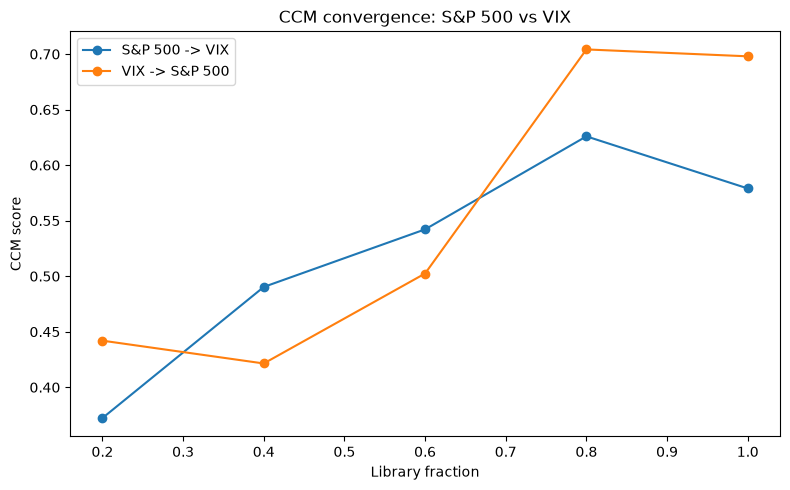


--------------------------------------------------------------------------------
Shuffle surrogate test for CCM direction S&P 500 -> VIX (embed_dim=2, lag=3)
--------------------------------------------------------------------------------
Real value:           0.639741
p-value:              0.0196
Surrogate mean:       0.066138
Surrogate median:     0.058815
Surrogate std:        0.044288
--------------------------------------------------------------------------------

--------------------------------------------------------------------------------
Bootstrap confidence interval for CCM direction S&P 500 -> VIX (embed_dim=2, lag=3)
--------------------------------------------------------------------------------
Real value:           0.639741
95% CI:               [0.007105, 0.198284]
Surrogate mean:       0.071664
Surrogate median:     0.058897
Surrogate std:        0.055746
--------------------------------------------------------------------------------

------------------------------

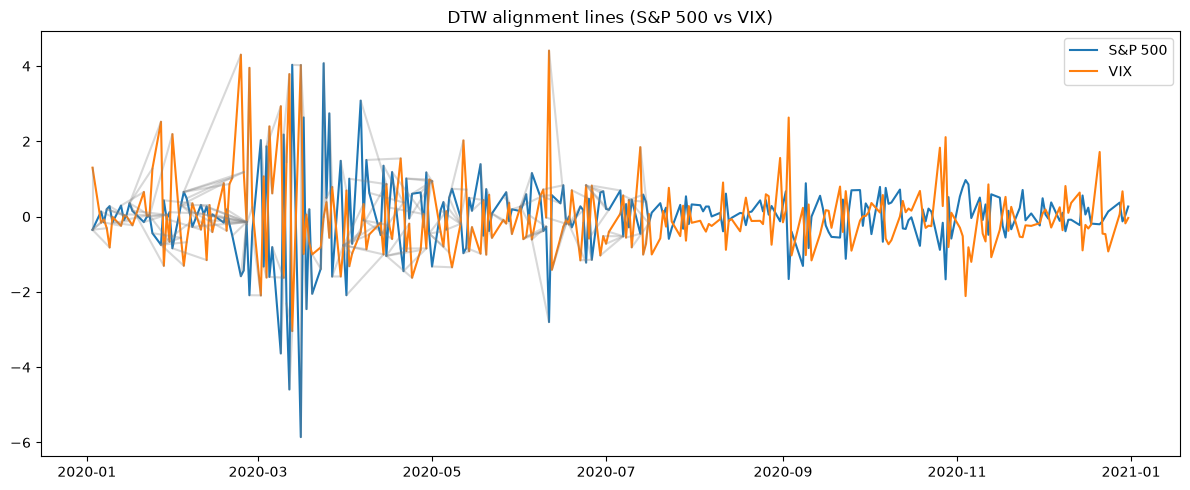

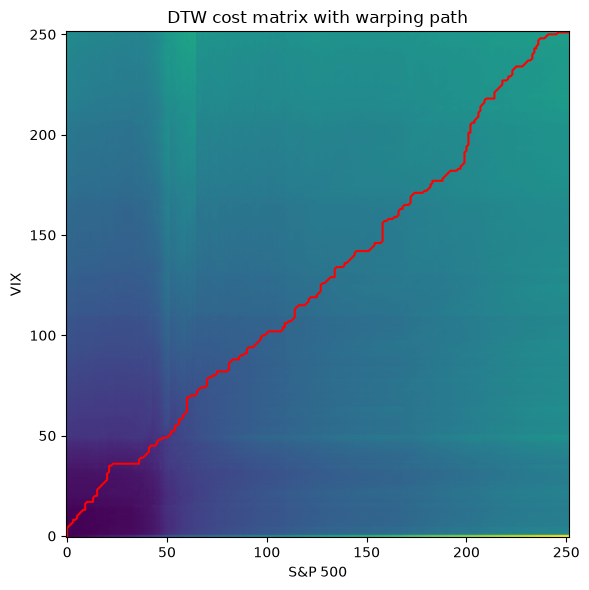


GRANGER CAUSALITY REPORT

Direction: S&P 500 -> VIX
     direction  lag    f_stat  p_value
S&P 500 -> VIX    1 13.516168 0.000290
S&P 500 -> VIX    2  6.135987 0.002511
S&P 500 -> VIX    3  5.364828 0.001361
S&P 500 -> VIX    4  3.950964 0.003998
S&P 500 -> VIX    5  3.377460 0.005758

Direction: VIX -> S&P 500
     direction  lag   f_stat  p_value
VIX -> S&P 500    1 2.446358 0.119073
VIX -> S&P 500    2 2.003424 0.137076
VIX -> S&P 500    3 3.288224 0.021405
VIX -> S&P 500    4 3.570865 0.007520
VIX -> S&P 500    5 3.014758 0.011704

Summary:
S&P 500 -> VIX: strongest evidence at lag 1 (F=13.516168, p=0.000289936)
VIX -> S&P 500: strongest evidence at lag 4 (F=3.570865, p=0.00751998)

Overall stronger direction by max F-stat: S&P 500 -> VIX

--------------------------------------------------------------------------------
Shuffle surrogate test for Granger direction S&P 500 -> VIX (maxlag=5)
--------------------------------------------------------------------------------
Real value: 

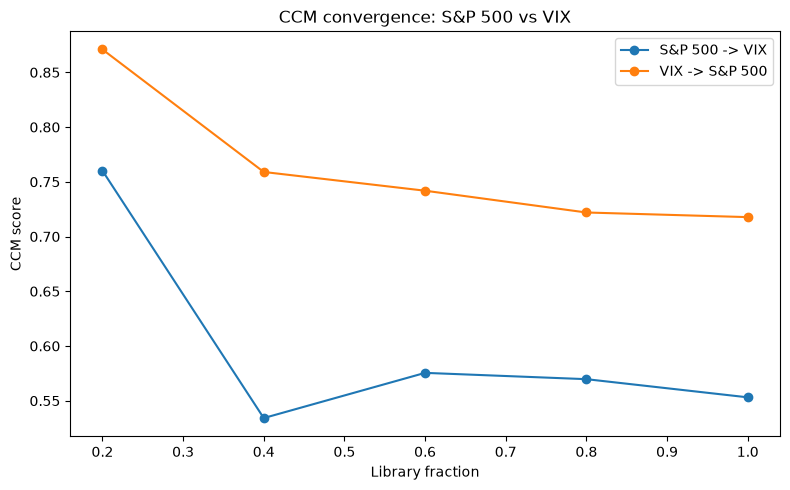


--------------------------------------------------------------------------------
Shuffle surrogate test for CCM direction S&P 500 -> VIX (embed_dim=2, lag=2)
--------------------------------------------------------------------------------
Real value:           0.608794
p-value:              0.0196
Surrogate mean:       0.072037
Surrogate median:     0.062827
Surrogate std:        0.061172
--------------------------------------------------------------------------------

--------------------------------------------------------------------------------
Bootstrap confidence interval for CCM direction S&P 500 -> VIX (embed_dim=2, lag=2)
--------------------------------------------------------------------------------
Real value:           0.608794
95% CI:               [0.002137, 0.147715]
Surrogate mean:       0.055891
Surrogate median:     0.042576
Surrogate std:        0.047493
--------------------------------------------------------------------------------

------------------------------

In [15]:
spx_vix_config = AnalysisConfig(
    run_lagged_cross_correlation=True,
    lcc_max_lag=10,
    run_dtw=True,
    plot_dtw_alignment=True,
    run_granger=True,
    granger_maxlag=5,
    run_granger_surrogates=True,
    run_te=True,
    te_max_lag=3,
    te_max_embed_dim=3,
    run_te_surrogates=True,
    run_ccm=True,
    ccm_max_lag=3,
    ccm_max_embed_dim=3,
    run_ccm_convergence=True,
    ccm_library_step=0.2,
    run_ccm_surrogates=True,
    n_surrogates=50,
    surrogate_seed=0,
    surrogate_method="both",
)

regime_results = {}
for regime_name, (start, end) in regimes.items():
    print("\n" + "=" * 100)
    print(f"REGIME: {regime_name} ({start} to {end})")
    print("=" * 100)

    spx_slice, vix_slice = slice_pair(loaded_full, start, end)

    regime_results[regime_name] = run_analysis_pipeline(
        spx_slice, vix_slice,
        "S&P 500", "VIX",
        preprocessing_config=spx_vix_preprocessing,
        analysis_config=spx_vix_config,
    )

In [ ]:
comparison_rows = []
for regime_name, results in regime_results.items():
    granger_summary = results["granger"]["summary"] if results["granger"] else {}
    best_spx_to_vix = granger_summary.get("best_one_to_two")
    best_vix_to_spx = granger_summary.get("best_two_to_one")

    te_summary = results["te_summary"]
    ccm_summary = results["ccm_summary"]

    comparison_rows.append({
        "regime": regime_name,
        "granger_F_spx_to_vix": best_spx_to_vix["f_stat"] if best_spx_to_vix else np.nan,
        "granger_F_vix_to_spx": best_vix_to_spx["f_stat"] if best_vix_to_spx else np.nan,
        "te_spx_to_vix": te_summary["one_to_two"]["one_two"] if te_summary["one_to_two"] else np.nan,
        "te_vix_to_spx": te_summary["two_to_one"]["two_one"] if te_summary["two_to_one"] else np.nan,
        "ccm_spx_to_vix": ccm_summary["one_to_two"]["one_two"] if ccm_summary["one_to_two"] else np.nan,
        "ccm_vix_to_spx": ccm_summary["two_to_one"]["two_one"] if ccm_summary["two_to_one"] else np.nan,
    })

comparison_table = pd.DataFrame(comparison_rows).set_index("regime")
comparison_table

,granger_F_spx_to_vix,granger_F_vix_to_spx,te_spx_to_vix,te_vix_to_spx,ccm_spx_to_vix,ccm_vix_to_spx
regime,,,,,,
full_sample,14.505303,27.444791,0.050373,0.055379,0.651195,0.745383
calm_2017,6.269482,2.014902,0.318826,0.285555,0.639741,0.697962
stress_2020,13.516168,3.570865,0.336405,0.269181,0.608794,0.717747


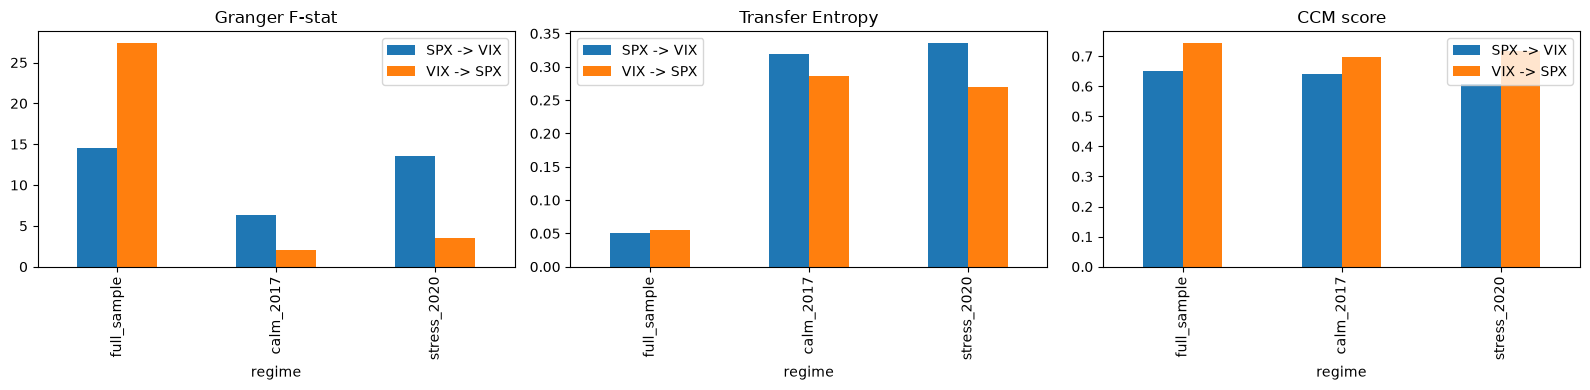

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
metrics = [
    ("granger_F_spx_to_vix", "granger_F_vix_to_spx", "Granger F-stat"),
    ("te_spx_to_vix", "te_vix_to_spx", "Transfer Entropy"),
    ("ccm_spx_to_vix", "ccm_vix_to_spx", "CCM score"),
]
for ax, (col_a, col_b, title) in zip(axes, metrics):
    comparison_table[[col_a, col_b]].plot(kind="bar", ax=ax)
    ax.set_title(title)
    ax.legend(["SPX -> VIX", "VIX -> SPX"])
plt.tight_layout()
plt.show()

## Interpreting the results

### Lagged cross-correlation (LCC): the clearest, most consistent finding

In all three regimes, SPX and VIX show a strong negative correlation
(around -0.72 to -0.74) at lag 0 -- meaning they move in opposite directions
on the *same day*, with no detectable one-day lead by either series. This
matches the leverage effect closely: it's a same-day relationship at daily
resolution, not one where either series predicts the other a day in advance.

### Granger causality: SPX -> VIX is the reliable direction in both sub-periods

In both calm_2017 and stress_2020, SPX -> VIX is the only direction that is
both strong and confirmed significant by the surrogate test, while VIX -> SPX
fails the surrogate test in both. This supports the leverage-effect story:
SPX's own moves help predict VIX's next moves, more than the reverse.

The full_sample result flips this (VIX -> SPX has the bigger F-stat), which is
a known statistical trap: blending many different market regimes (calm years,
crash years, recovery years) into one long dataset can produce misleading
patterns that don't represent any single real relationship. This is exactly
why splitting into sub-periods was the right approach.

### Transfer entropy: no significant result in either sub-regime

Both directions failed the surrogate significance test in calm_2017 and
stress_2020 (p-values close to 1.0, meaning the real result looked no
different from random noise). This likely reflects two things: SPX/VIX
returns are close to a "straight-line" (linear) relationship, which
ordinal-pattern TE is not well-suited to detect (see Notebook 1's synthetic
example for the same limitation), and only ~250 daily data points per year is
a small sample for this specific method.

### CCM: strong in both directions everywhere -- likely reflects mechanical linkage, not two-way causation

Every regime shows high, statistically significant CCM scores in both
directions. Given that VIX is calculated directly from SPX option prices,
this is expected: they aren't two independent systems influencing each other,
they're two measurements of the same underlying market. High mutual
predictability here mostly reflects that structural link rather than proving
genuine two-way economic causation.

The CCM convergence check (does the score stabilize as we add more data)
shows that none of the six direction/regime combinations converge perfectly
cleanly, which likely reflects the small sample size (~250 points per year).

## Takeaways

- The SPX-VIX leverage effect shows up clearly and consistently as a same-day
  (lag 0), strong negative correlation across every regime tested.
- Granger causality robustly supports SPX -> VIX (not the reverse) as the
  significant, surrogate-validated direction in both the calm (2017) and
  stress (2020) sub-periods -- consistent with the leverage-effect story.
  The full-sample result reverses this, illustrating how blending different
  market regimes together can produce misleading causal signals.
- Transfer entropy found no significant signal in either sub-regime, likely
  due to the near-linear nature of this relationship and a limited sample
  size for the ordinal-pattern method used here.
- CCM found strong, largely symmetric scores in both directions across all
  regimes, most plausibly reflecting VIX's mechanical derivation from SPX
  options rather than independent two-way causation. Convergence diagnostics
  suggest some caution is warranted in all regimes, not just one, given the
  limited sample sizes involved.
- Note: this study uses daily closing prices of the spot indices, not
  intraday futures data. Some published research on VIX/SPX lead-lag effects
  uses high-frequency futures data and finds different dynamics (e.g. VIX
  futures sometimes leading SPX futures via hedging flows) -- that is a
  distinct question from what this daily-frequency study tests.